# RF Fingerprinting Notebook

Notebook-first workflow for real vs complex RF encoders with synthetic fallback data.

Modes:
- `fast`: quick smoke tests (small data, short training).
- `base`: balanced default for iteration.
- `full`: longer run for stronger comparison numbers.

In [1]:
import numpy as np
import torch

from rf_fingerprinting.config import load_config
from rf_fingerprinting.data_io import load_or_generate_npz
from rf_fingerprinting.datasets import IQDataset, TwoViewIQDataset, split_indices
from rf_fingerprinting.evaluate import collect_logits, evaluate_logits
from rf_fingerprinting.finetune import finetune_classifier
from rf_fingerprinting.logging_utils import save_scorecard_csv
from rf_fingerprinting.models_complex import ComplexEncoder1D
from rf_fingerprinting.models_real import RealEncoder1D
from rf_fingerprinting.open_set import open_set_auc
from rf_fingerprinting.pretrain import pretrain_simclr
from rf_fingerprinting.probe import run_linear_probe
from rf_fingerprinting.transforms import augment_iq
from rf_fingerprinting.visualize import plot_history, plot_iq_views

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

MODE = 'full'  # choose from: 'fast', 'base', 'full'
CONFIG_BY_MODE = {
    'fast': 'configs/rf_fp_fast.yaml',
    'base': 'configs/rf_fp_base.yaml',
    'full': 'configs/rf_fp_full.yaml',
}

DATASET_PATH = ''  # optional .npz path
OUTPUT_DIR_OVERRIDE = ''  # optional absolute or relative output dir override

cfg = load_config(path=CONFIG_BY_MODE[MODE], mode=MODE)
if DATASET_PATH:
    cfg.dataset_path = DATASET_PATH
if OUTPUT_DIR_OVERRIDE:
    cfg.output_dir = OUTPUT_DIR_OVERRIDE

print({
    'mode': cfg.mode,
    'n_samples': cfg.n_samples,
    'batch_size': cfg.batch_size,
    'pretrain_epochs': cfg.pretrain_epochs,
    'finetune_epochs': cfg.finetune_epochs,
    'output_dir': cfg.output_dir,
})
cfg

{'mode': 'full', 'n_samples': 4000, 'batch_size': 128, 'pretrain_epochs': 10, 'finetune_epochs': 8, 'output_dir': '/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full'}


RFConfig(mode='full', dataset_path='', output_dir='/home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full', seed=7, seq_len=256, n_devices=8, n_sessions=3, n_samples=4000, test_size=0.2, val_size=0.2, batch_size=128, embed_dim=64, pretrain_epochs=10, finetune_epochs=8, lr=0.001, weight_decay=0.0001, temperature=0.2, noise_std=0.03, phase_jitter_rad=0.3, time_shift=8)

In [2]:
data = load_or_generate_npz(cfg)
print({k: v.shape for k, v in data.items()})
print('num_devices:', int(data['device_id'].max()) + 1)
print('num_sessions:', int(data['session_id'].max()) + 1)

{'iq': (4000, 256), 'device_id': (4000,), 'session_id': (4000,)}
num_devices: 8
num_sessions: 3


In [3]:
splits = split_indices(data['iq'].shape[0], cfg.test_size, cfg.val_size, cfg.seed, labels=data['device_id'])
train_ds = IQDataset(data['iq'][splits['train']], data['device_id'][splits['train']])
val_ds = IQDataset(data['iq'][splits['val']], data['device_id'][splits['val']])
test_ds = IQDataset(data['iq'][splits['test']], data['device_id'][splits['test']])
num_classes = int(data['device_id'].max()) + 1
len(train_ds), len(val_ds), len(test_ds), num_classes

(2560, 640, 800, 8)

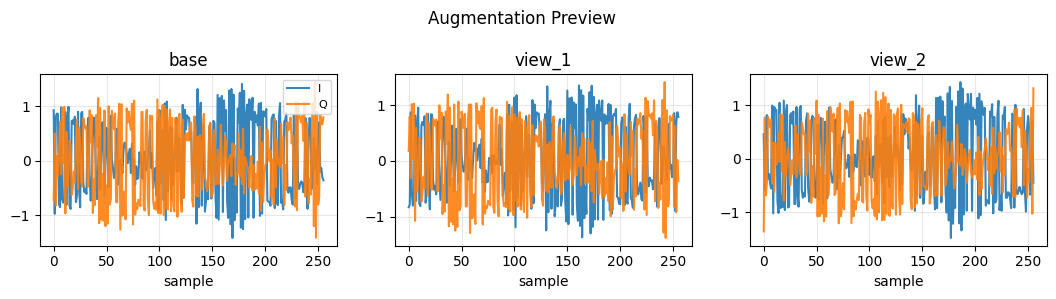

In [4]:
sample = data['iq'][0]
v1 = augment_iq(sample, cfg.noise_std, cfg.phase_jitter_rad, cfg.time_shift, seed=cfg.seed + 1)
v2 = augment_iq(sample, cfg.noise_std, cfg.phase_jitter_rad, cfg.time_shift, seed=cfg.seed + 2)
_ = plot_iq_views(sample, [v1, v2], title='Augmentation Preview')

In [5]:
two_view_ds = TwoViewIQDataset(data['iq'][splits['train']], cfg)

def run_pipeline(name):
    if name == 'real':
        encoder = RealEncoder1D(embed_dim=cfg.embed_dim)
    else:
        encoder = ComplexEncoder1D(embed_dim=cfg.embed_dim)

    pre_hist = pretrain_simclr(encoder, two_view_ds, cfg, device)
    probe_metrics = run_linear_probe(encoder.to(device), train_ds, test_ds, device)

    ft_model, ft_hist = finetune_classifier(
        encoder=encoder.to(device),
        train_dataset=train_ds,
        val_dataset=val_ds,
        num_classes=num_classes,
        cfg=cfg,
        device=device,
    )

    test_logits, test_labels = collect_logits(ft_model, test_ds, device)
    eval_metrics = evaluate_logits(test_logits, test_labels)

    ood_logits = test_logits + 0.75 * np.random.randn(*test_logits.shape)
    os_metrics = open_set_auc(test_logits, ood_logits)

    row = {
        'encoder': name,
        'pretrain_final_loss': float(pre_hist['loss'][-1]),
        'probe_acc': float(probe_metrics['probe_acc']),
        'test_acc': float(eval_metrics['acc']),
        'test_f1_macro': float(eval_metrics['f1_macro']),
        'open_set_auroc': float(os_metrics['open_set_auroc']),
    }
    return row, pre_hist, ft_hist

real_row, real_pre_hist, real_ft_hist = run_pipeline('real')
complex_row, complex_pre_hist, complex_ft_hist = run_pipeline('complex')
scorecard = [real_row, complex_row]
scorecard

[{'encoder': 'real',
  'pretrain_final_loss': 1.80272433757782,
  'probe_acc': 0.845,
  'test_acc': 0.90375,
  'test_f1_macro': 0.9032776417646085,
  'open_set_auroc': 0.49503125000000003},
 {'encoder': 'complex',
  'pretrain_final_loss': 1.7641746819019317,
  'probe_acc': 0.8475,
  'test_acc': 0.84375,
  'test_f1_macro': 0.8431829046549999,
  'open_set_auroc': 0.4955453125}]

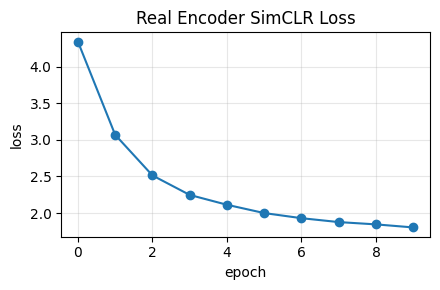

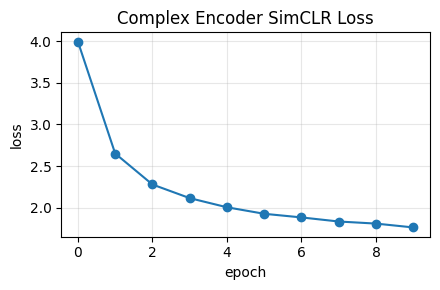

In [6]:
_ = plot_history(real_pre_hist, 'loss', 'Real Encoder SimCLR Loss')
_ = plot_history(complex_pre_hist, 'loss', 'Complex Encoder SimCLR Loss')

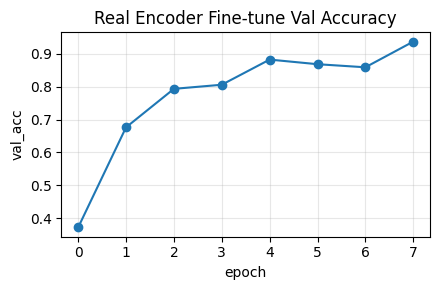

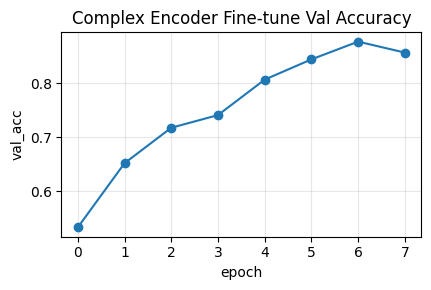

In [7]:
_ = plot_history(real_ft_hist, 'val_acc', 'Real Encoder Fine-tune Val Accuracy')
_ = plot_history(complex_ft_hist, 'val_acc', 'Complex Encoder Fine-tune Val Accuracy')

In [8]:
scorecard_path = f"{cfg.output_dir}/scorecard.csv"
save_scorecard_csv(scorecard_path, scorecard)
print('scorecard_csv:', scorecard_path)
scorecard

scorecard_csv: /home/hinson/projects/hinsonan.github.io/code_examples/complex_vs_real_nn/rf_fingerprinting/outputs/rf_fingerprinting_full/scorecard.csv


[{'encoder': 'real',
  'pretrain_final_loss': 1.80272433757782,
  'probe_acc': 0.845,
  'test_acc': 0.90375,
  'test_f1_macro': 0.9032776417646085,
  'open_set_auroc': 0.49503125000000003},
 {'encoder': 'complex',
  'pretrain_final_loss': 1.7641746819019317,
  'probe_acc': 0.8475,
  'test_acc': 0.84375,
  'test_f1_macro': 0.8431829046549999,
  'open_set_auroc': 0.4955453125}]